# Illuminating the Solar Narrative With Data Transparency

In early 2025, Severin Borenstein posted [“Guess What Didn’t Kill Rooftop Solar”](https://energyathaas.wordpress.com/2025/01/27/guess-what-didnt-kill-rooftop-solar/#2484e8ee-f811-4a42-b744-1e17520f6b34-link) to the Energy Institute at Haas blog. In it, he argues that the California rooftop solar industry is quite healthy despite the implementation of the Net Billing Tariff (NBT/NEM 3.0), which drastically lowered compensation for rooftop solar exports. To back this statement he showed a bar graph depicting the “market rebound” after NBT, where sales after NBT seemingly dwarfs sales before NBT for three different time intervals.

Just looking at that bar graph, one would be inclined to believe that rooftop solar sales barely skipped a beat, and in fact sales improved with NBT. But what’s really important to note is that the before and after aggregates pivot around the NBT decision of December 2022, not the NBT implementation of April 2023. To see how this choice of before/after point affects the outcome, let’s plot the number of applications over time, with the time intervals Borenstein aggregates over superimposed.


In [1]:
# First import packages and code
import datetime
import glob
import numpy as np
import numpy_financial as npf
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import data_analysis as data_analysis
import data_visualization as data_vis

import plotly.io as pio
from plotly.offline import init_notebook_mode

pio.renderers.default = "notebook_connected"
init_notebook_mode(connected=True)

In [2]:
# Set paths and load data
data_dir = '/Users/jenny.folkesson/Data/solar/'
dgstats_dir = os.path.join(data_dir, 'applications_20251231/')
archive_dir = os.path.join(data_dir, 'Interconnection_Applications_Dataset_2024-12-31/')

df_total = data_analysis.read_stored_data(dgstats_dir, "dgstats_preprocessed_data.csv", archive_dir)

Reading existing file:  /Users/jenny.folkesson/Data/solar/applications_20251231/dgstats_preprocessed_data.csv


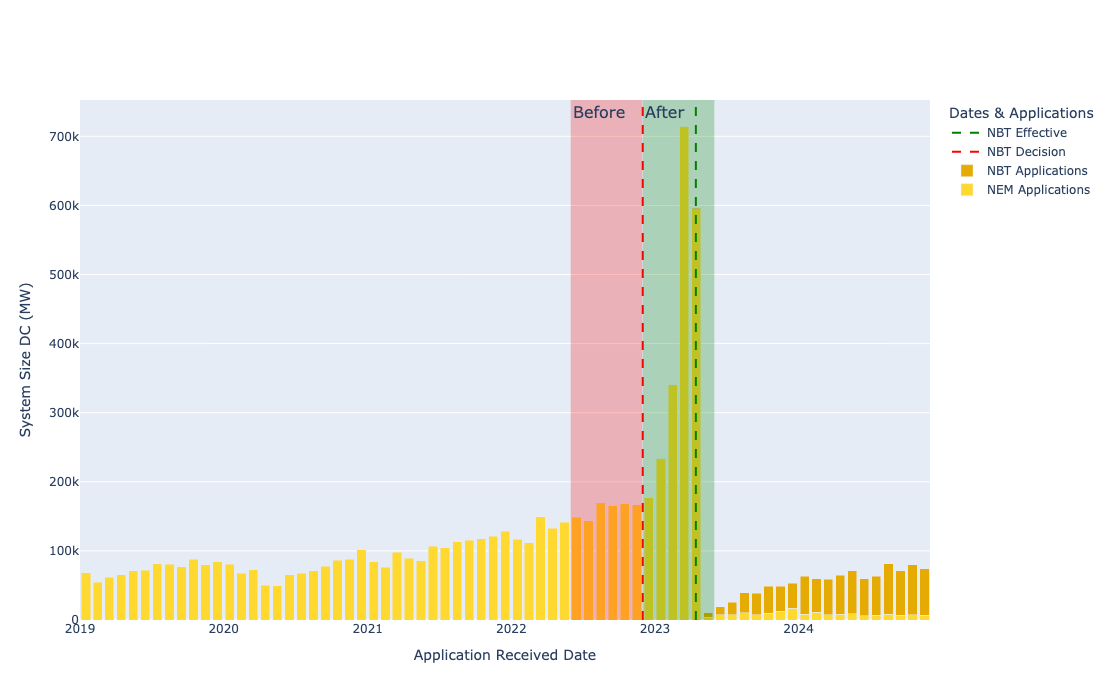

In [14]:
# When Borenstein wrote his blog post, the data in DGStats were from November 30 and earlier so we'll use that here
max_date = "2024-11-30"
import importlib
importlib.reload(data_vis)
fig = data_vis.what_didnt_kill_rooftop_solar_graph(df_total, max_date=max_date)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "what_didnt_kill_rooftop_solar.png"), scale=5)
fig.write_html(os.path.join(data_dir, "what_didnt_kill_rooftop_solar.html"),
               include_plotlyjs='cdn',
               full_html=False,
               config={"responsive": True}
)